In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
df_m6a = pd.read_csv("data/STAR_exec_times_m6a.csv")
df_m7a = pd.read_csv("data/STAR_exec_times_m7a.csv")

In [4]:
#S(P) = T(1) / T(P)
#E(P) = S(P) / P
def calculate_speedup_efficiency(df):
    df["speedup"] = df.groupby('srr_id').apply(lambda group: group[group['n_threads'] == 1]['execution_time_seconds'].values[0] / group['execution_time_seconds']).reset_index().sort_values("level_1").reset_index()["execution_time_seconds"]
    df["efficiency"] = df["speedup"] / df["n_threads"] * 100
    return df

df_m6a = calculate_speedup_efficiency(df_m6a)
df_m7a = calculate_speedup_efficiency(df_m7a)

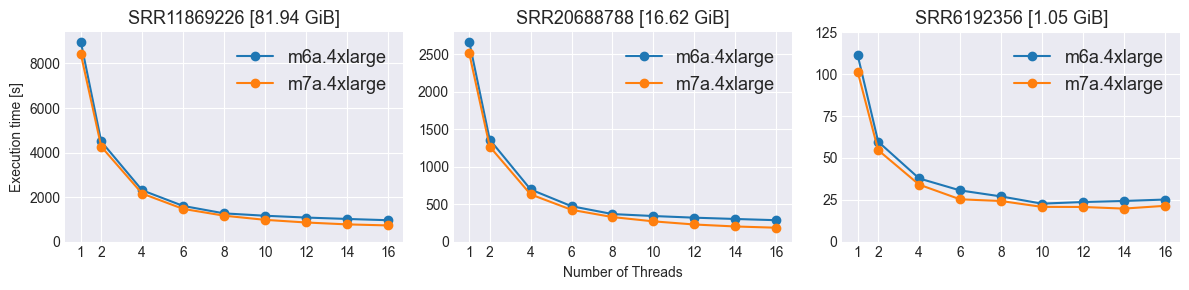

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

for i, (name, group) in enumerate(df_m6a.groupby("srr_id")):
    group.plot(x='n_threads', y='execution_time_seconds', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='')
    axs[i].set_xticks(group["n_threads"])

for i, (name, group) in enumerate(df_m7a.groupby("srr_id")):
    group.plot(x='n_threads', y='execution_time_seconds', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='')

    if i == 0:
        axs[i].set_yticks([0, 2000, 4000, 6000, 8000])
    if i == 1:
        axs[i].set_yticks([0, 500, 1000, 1500, 2000, 2500])
    if i == 2:
        axs[i].set_yticks([0, 25, 50, 75, 100, 125])

    axs[i].set_title(f"{name} [{round(group['fastq_size_MiB'].iloc[0] / 1024, 2)} GiB]", fontsize=13)
    axs[i].tick_params(axis='x', labelsize=10)
    axs[i].tick_params(axis='y', labelsize=10)
    axs[i].legend(fontsize=13)

# plt.suptitle("STAR --runThreadN vs Execution Time", fontsize=16)
axs[0].set_ylabel('Execution time [s]', fontsize=10)
axs[1].set_xlabel('Number of Threads', fontsize=10)
plt.tight_layout()
plt.savefig("plots/STAR_scalability.pdf", format="pdf", bbox_inches='tight')

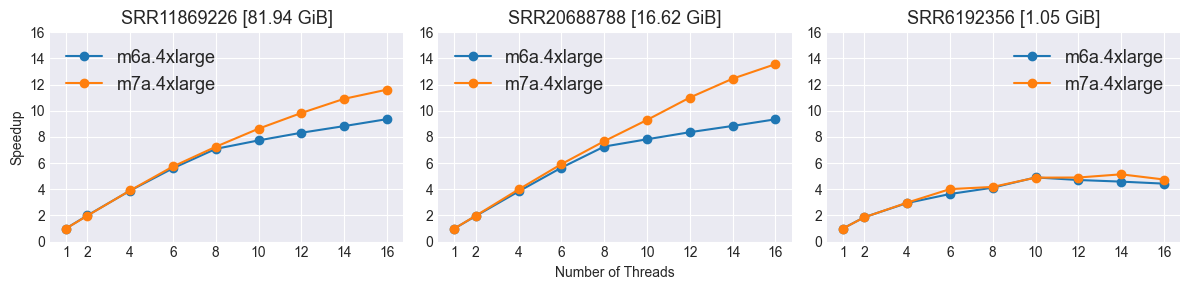

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

for i, (name, group) in enumerate(df_m6a.groupby("srr_id")):
    group.plot(x='n_threads', y='speedup', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='').set_yticks(np.linspace(0, 16, 9))
    axs[i].set_xticks(group["n_threads"])

for i, (name, group) in enumerate(df_m7a.groupby("srr_id")):
    group.plot(x='n_threads', y='speedup', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='').set_yticks(np.linspace(0, 16, 9))

    axs[i].set_title(f"{name} [{round(group['fastq_size_MiB'].iloc[0] / 1024, 2)} GiB]", fontsize=13)
    axs[i].tick_params(axis='x', labelsize=10)
    axs[i].tick_params(axis='y', labelsize=10)
    axs[i].legend(fontsize=13)

# plt.suptitle("STAR --runThreadN vs Speedup", fontsize=16)
axs[0].set_ylabel('Speedup', fontsize=10)
axs[1].set_xlabel('Number of Threads', fontsize=10)
plt.tight_layout()
plt.savefig("plots/STAR_speedup.pdf", format="pdf", bbox_inches='tight')

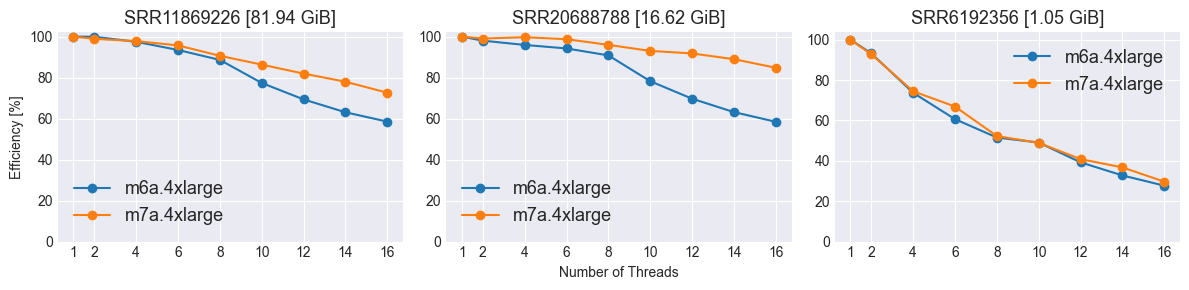

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

for i, (name, group) in enumerate(df_m6a.groupby("srr_id")):
    group.plot(x='n_threads', y='efficiency', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='').set_yticks(np.linspace(0, 100, 6))
    axs[i].set_xticks(group["n_threads"])

for i, (name, group) in enumerate(df_m7a.groupby("srr_id")):
    group.plot(x='n_threads', y='efficiency', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='').set_yticks(np.linspace(0, 100, 6))

    axs[i].set_title(f"{name} [{round(group['fastq_size_MiB'].iloc[0] / 1024, 2)} GiB]", fontsize=13)
    axs[i].tick_params(axis='x', labelsize=10)
    axs[i].tick_params(axis='y', labelsize=10)
    axs[i].legend(fontsize=13)

# plt.suptitle("STAR --runThreadN vs Efficiency", fontsize=16)
axs[0].set_ylabel('Efficiency [%]', fontsize=10)
axs[1].set_xlabel('Number of Threads', fontsize=10)
plt.tight_layout()
plt.savefig("plots/STAR_efficiency.pdf", bbox_inches='tight')